# FarrahAI — Notebook 2: Topic Classification

This notebook demonstrates:
- Loading your labeled topic dataset from CSV
- Building TF-IDF features for text classification
- Training and comparing Logistic Regression, Random Forest, and XGBoost (if available)
- Saving the best model artifacts
- Predicting topics for OCR text files in `data/outputs/ocr_text/AI_ML`

TF-IDF full form: **Term Frequency-Inverse Document Frequency**.
It converts text into numeric features by giving high weight to terms that are frequent in a document but not frequent across all documents.


In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder

from modules.ml_models import (
    build_tfidf_features,
    compare_classifiers,
    save_model,
)

print('Ready')


Ready


## Step 1: Load labeled topic dataset

Supported schemas:
- `text,topic`
- `chunk_id,text,topic,unit_no,unit_name,page_start,page_end,source`

This cell auto-selects the first available CSV path.


In [2]:
DATASET_CANDIDATES = [
    Path('../data/processed/farrahai_topic_dataset.csv'),
    Path('../data/processed/farrahai_topic_dataset_text_topic.csv'),
]

DATASET_PATH = None
for p in DATASET_CANDIDATES:
    if p.exists():
        DATASET_PATH = p
        break

if DATASET_PATH is None:
    raise FileNotFoundError('No labeled topic dataset found in expected paths.')

print(f'Using dataset: {DATASET_PATH}')
df = pd.read_csv(DATASET_PATH)

required = {'text', 'topic'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {missing}. Found: {list(df.columns)}')

# Keep required columns + metadata if present
meta_cols = [c for c in ['chunk_id', 'unit_no', 'unit_name', 'page_start', 'page_end', 'source'] if c in df.columns]
keep_cols = ['text', 'topic'] + meta_cols
df = df[keep_cols].copy()

# Basic cleanup
df['text'] = df['text'].astype(str).str.strip()
df['topic'] = df['topic'].astype(str).str.strip()
df = df[(df['text'] != '') & (df['topic'] != '')]
df = df.drop_duplicates(subset=['text', 'topic']).reset_index(drop=True)

print(f'Dataset size: {len(df)}')
print(f'Unique topics: {df["topic"].nunique()}')
display(df.head(5))
print('Topic distribution:')
print(df['topic'].value_counts())


Using dataset: ../data/processed/farrahai_topic_dataset.csv
Dataset size: 1266
Unique topics: 14


,text,topic,chunk_id,unit_no,unit_name,page_start,page_end,source
0,Unit 01: Introduction to Machine Learning Unit...,Introduction to Machine Learning,U01_0000,1,Introduction to Machine Learning,4,4,DECAP737_MACHINE_LEARNING.pdf
1,Machine Learning Summary Keywords Self Assessm...,Introduction to Machine Learning,U01_0001,1,Introduction to Machine Learning,4,4,DECAP737_MACHINE_LEARNING.pdf
2,types.  Understanding the major tasks in prep...,Introduction to Machine Learning,U01_0002,1,Introduction to Machine Learning,4,4,DECAP737_MACHINE_LEARNING.pdf
3,"performance measure, if the performance at the...",Introduction to Machine Learning,U01_0003,1,Introduction to Machine Learning,4,4,DECAP737_MACHINE_LEARNING.pdf
4,approaches are discussed using examples. The p...,Introduction to Machine Learning,U01_0004,1,Introduction to Machine Learning,4,4,DECAP737_MACHINE_LEARNING.pdf


Topic distribution:
topic
Python Basics                       134
Neural Network Implementation       133
Data Visualization                  121
Physical Layer                      117
Classification                      101
Introduction to Numpy                98
Data Pre-Processing                  89
Ensemble Methods                     87
Introduction to Machine Learning     84
Neural Networks                      84
Classification Algorithms            77
Clustering                           60
Implementation of Pre-processing     48
Classification Implementation        33
Name: count, dtype: int64


## Step 2: Build TF-IDF features

TF-IDF turns each text chunk into a weighted sparse vector.


In [3]:
MAX_FEATURES = 5000

vectorizer, X = build_tfidf_features(df['text'].tolist(), max_features=MAX_FEATURES)
y = df['topic'].tolist()

print(f'Feature matrix shape: {X.shape}')
print(f'Vocabulary size: {len(vectorizer.vocabulary_)}')
print(f'Number of classes: {len(set(y))}')


Feature matrix shape: (1266, 5000)
Vocabulary size: 5000
Number of classes: 14


## Step 3: Compare classifiers and choose best model


In [4]:
comparison_df = compare_classifiers(X, y)

if comparison_df.empty:
    raise RuntimeError('No classifier could be trained. Check package dependencies.')

comparison_df = comparison_df.sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
best_model_type = comparison_df.loc[0, 'Model']

comparison_df.to_csv('../outputs/classifier_comparison.csv', index=False)
print('Saved: ../outputs/classifier_comparison.csv')
print(f'Best model by F1 (macro): {best_model_type}')

display(comparison_df)


/home/harsh/Desktop/CUK/FarrahAI/farrahai_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



── LOGISTIC Topic Classifier ──────────────────
  Accuracy:    0.748
  F1 (macro):  0.6769
  F1 (weighted): 0.7314

                                  precision    recall  f1-score   support

                  Classification       0.59      0.65      0.62        20
       Classification Algorithms       0.55      0.40      0.46        15
   Classification Implementation       1.00      0.14      0.25         7
                      Clustering       0.60      0.50      0.55        12
             Data Pre-Processing       0.58      0.83      0.68        18
              Data Visualization       0.81      0.88      0.84        24
                Ensemble Methods       0.87      0.76      0.81        17
Implementation of Pre-processing       1.00      0.20      0.33        10
Introduction to Machine Learning       0.82      0.82      0.82        17
           Introduction to Numpy       0.76      0.80      0.78        20
   Neural Network Implementation       0.77      1.00      0.87     

/home/harsh/Desktop/CUK/FarrahAI/farrahai_env/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [22:19:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



── XGBOOST Topic Classifier ──────────────────
  Accuracy:    0.6299
  F1 (macro):  0.5703
  F1 (weighted): 0.6232

                                  precision    recall  f1-score   support

                  Classification       0.72      0.65      0.68        20
       Classification Algorithms       0.39      0.47      0.42        15
   Classification Implementation       0.50      0.14      0.22         7
                      Clustering       0.43      0.50      0.46        12
             Data Pre-Processing       0.47      0.50      0.49        18
              Data Visualization       0.63      0.71      0.67        24
                Ensemble Methods       0.80      0.47      0.59        17
Implementation of Pre-processing       0.30      0.30      0.30        10
Introduction to Machine Learning       0.65      0.65      0.65        17
           Introduction to Numpy       0.68      0.65      0.67        20
   Neural Network Implementation       0.74      0.85      0.79     

,Model,Accuracy,F1 (macro),F1 (weighted)
0,logistic,0.7480,0.6769,0.7314
1,random_forest,0.7244,0.6642,0.7103
2,xgboost,0.6299,0.5703,0.6232


## Step 4: Visualize model comparison


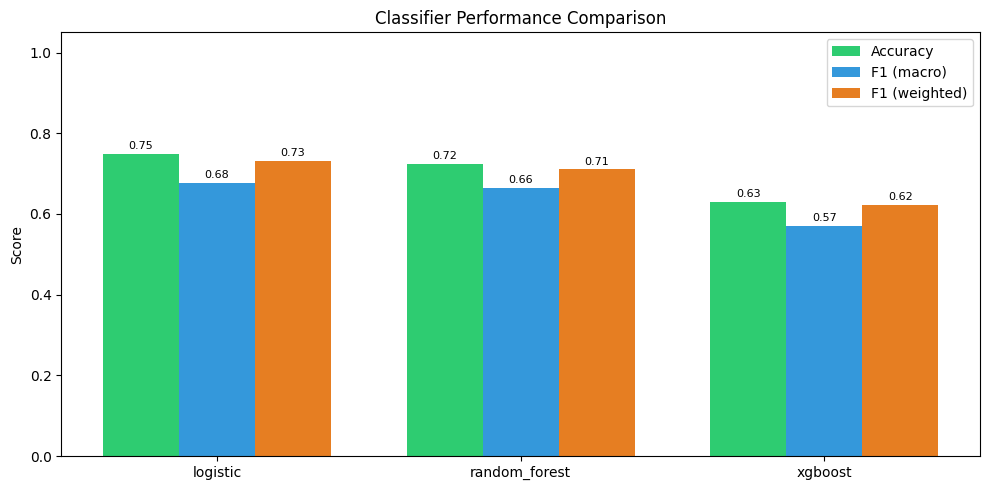

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.25

b1 = ax.bar(x - width, comparison_df['Accuracy'], width, label='Accuracy', color='#2ecc71')
b2 = ax.bar(x, comparison_df['F1 (macro)'], width, label='F1 (macro)', color='#3498db')
b3 = ax.bar(x + width, comparison_df['F1 (weighted)'], width, label='F1 (weighted)', color='#e67e22')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Classifier Performance Comparison')
ax.legend()
ax.bar_label(b1, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(b2, fmt='%.2f', padding=2, fontsize=8)
ax.bar_label(b3, fmt='%.2f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/classifier_comparison_chart.png', dpi=150)
plt.show()


## Step 5: Train final model, show confusion matrix, save artifacts


/home/harsh/Desktop/CUK/FarrahAI/farrahai_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Classification report:
                                  precision    recall  f1-score   support

                  Classification       0.59      0.65      0.62        20
       Classification Algorithms       0.55      0.40      0.46        15
   Classification Implementation       1.00      0.14      0.25         7
                      Clustering       0.60      0.50      0.55        12
             Data Pre-Processing       0.58      0.83      0.68        18
              Data Visualization       0.81      0.88      0.84        24
                Ensemble Methods       0.87      0.76      0.81        17
Implementation of Pre-processing       1.00      0.20      0.33        10
Introduction to Machine Learning       0.82      0.82      0.82        17
           Introduction to Numpy       0.76      0.80      0.78        20
   Neural Network Implementation       0.77      1.00      0.87        27
                 Neural Networks       1.00      0.65      0.79        17
              

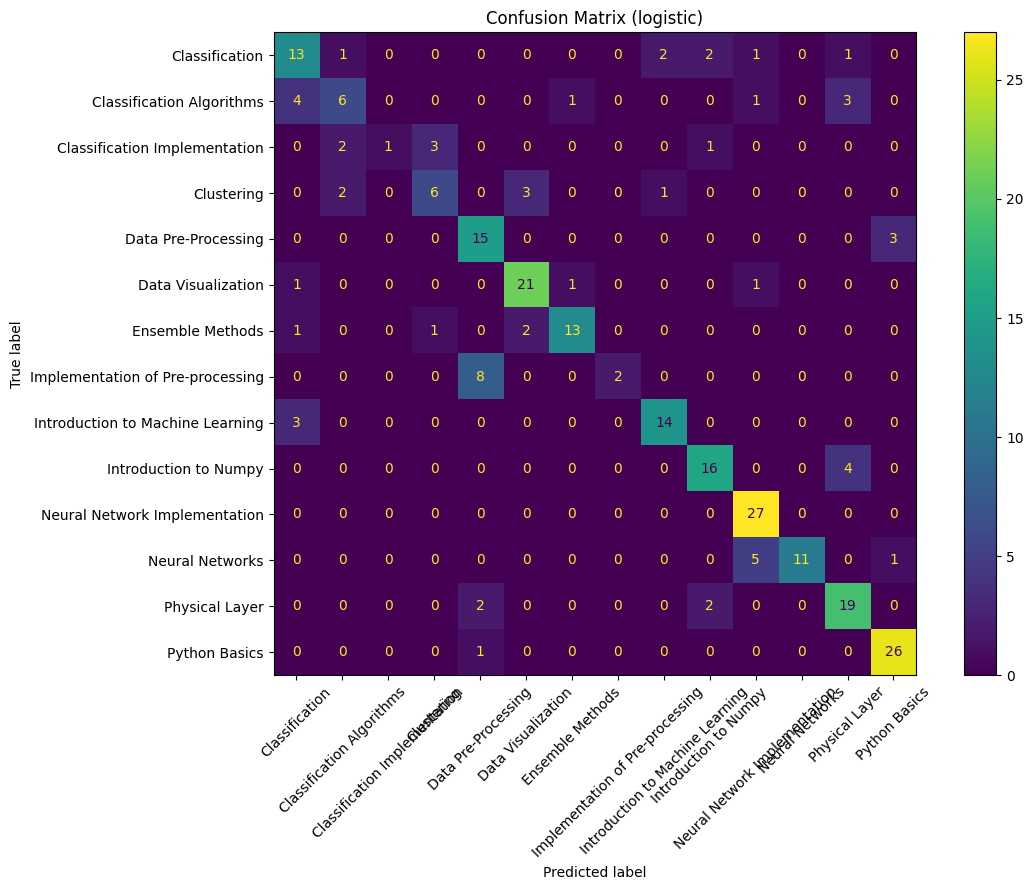

Saved model artifacts to ../models/


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


def make_classifier(name: str):
    if name == 'logistic':
        return LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)
    if name == 'random_forest':
        return RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    if name == 'xgboost':
        try:
            from xgboost import XGBClassifier
            return XGBClassifier(
                n_estimators=250,
                max_depth=6,
                learning_rate=0.1,
                eval_metric='mlogloss',
                random_state=42,
                n_jobs=-1,
            )
        except Exception as e:
            print(f'XGBoost unavailable ({e}). Falling back to Logistic Regression.')
            return LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)
    raise ValueError(f'Unknown model name: {name}')

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

final_model = make_classifier(best_model_type)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print('Classification report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title(f'Confusion Matrix ({best_model_type})')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_best_model.png', dpi=150)
plt.show()

# Save artifacts
save_model(final_model, '../models/topic_classifier_best.pkl')
save_model(le, '../models/topic_label_encoder.pkl')
save_model(vectorizer, '../models/topic_tfidf_vectorizer.pkl')
print('Saved model artifacts to ../models/')


## Step 6: Predict topics for OCR text files

This tests the trained model on extracted OCR text files from `data/outputs/ocr_text/AI_ML`.


In [8]:
OCR_TEXT_DIR = Path('../data/outputs/ocr_text/AI_ML')
ocr_files = sorted(OCR_TEXT_DIR.glob('*.txt'))

print(f'Found {len(ocr_files)} OCR text files in: {OCR_TEXT_DIR}')

records = []
for p in ocr_files:
    txt = p.read_text(encoding='utf-8', errors='ignore').strip()
    if not txt:
        continue

    X_one = vectorizer.transform([txt])
    y_hat = final_model.predict(X_one)[0]
    topic_hat = le.inverse_transform([y_hat])[0]

    confidence = None
    if hasattr(final_model, 'predict_proba'):
        try:
            confidence = float(final_model.predict_proba(X_one).max())
        except Exception:
            confidence = None

    records.append({
        'file': p.name,
        'predicted_topic': topic_hat,
        'confidence': confidence,
        'text_chars': len(txt),
    })

pred_df = pd.DataFrame(records).sort_values(['predicted_topic', 'file']).reset_index(drop=True)

pred_out = Path('../outputs/ocr_topic_predictions.csv')
pred_df.to_csv(pred_out, index=False)

print(f'Saved: {pred_out}')
print('\nPredicted topic counts:')
print(pred_df['predicted_topic'].value_counts())
display(pred_df.head(50))


Found 187 OCR text files in: ../data/outputs/ocr_text/AI_ML
Saved: ../outputs/ocr_topic_predictions.csv

Predicted topic counts:
predicted_topic
Neural Network Implementation       20
Physical Layer                      19
Python Basics                       19
Data Visualization                  18
Data Pre-Processing                 17
Introduction to Numpy               15
Classification                      13
Ensemble Methods                    13
Introduction to Machine Learning    13
Classification Algorithms           11
Neural Networks                      9
Clustering                           8
Classification Implementation        6
Implementation of Pre-processing     6
Name: count, dtype: int64


,file,predicted_topic,confidence,text_chars
0,DECAP737_MACHINE_LEARNING_pages-to-jpg-0089.txt,Classification,0.300512,2002
1,DECAP737_MACHINE_LEARNING_pages-to-jpg-0090.txt,Classification,0.857369,2206
2,DECAP737_MACHINE_LEARNING_pages-to-jpg-0091.txt,Classification,0.663612,1680
3,DECAP737_MACHINE_LEARNING_pages-to-jpg-0092.txt,Classification,0.679297,1080
4,DECAP737_MACHINE_LEARNING_pages-to-jpg-0093.txt,Classification,0.712313,3324
5,DECAP737_MACHINE_LEARNING_pages-to-jpg-0094.txt,Classification,0.803276,2434
6,DECAP737_MACHINE_LEARNING_pages-to-jpg-0095.txt,Classification,0.805957,1361
7,DECAP737_MACHINE_LEARNING_pages-to-jpg-0096.txt,Classification,0.395525,2013
8,DECAP737_MACHINE_LEARNING_pages-to-jpg-0097.txt,Classification,0.548279,1538
9,DECAP737_MACHINE_LEARNING_pages-to-jpg-0098.txt,Classification,0.774932,1704
